# Extended NJL EoS engine — usage and validation

`eos.enjl` implements the extended NJL model of

> C.-J. Xia, *Quarkyonic matter and compact stars in an extended NJL model*,
> Phys. Rev. D **110**, 014022 (2024), arXiv:2405.02946

Baryons are treated as clusters of three quarks, so nucleonic matter, quark
matter and the transitions between them all come out of **one** functional
rather than two models glued together at a phase boundary. The independent
unknowns of the mean field are just the three quark masses; everything else —
baryon masses, scalar densities, vector fields, rearrangement terms — follows
algebraically.

This notebook is both a tour and a check. Every section below recomputes
something that can be compared against the author's own tables in
`test/enjl/reference/`, and prints the residual. If a cell prints a number
larger than the one quoted next to it, something has regressed.

**What is validated as of this notebook**

| | status |
|---|---|
| vacuum gap solution, $E_0$ | reproduces the published values |
| fixed-composition mean field (`solve_point`) | $\mu_i$ to 0.05 MeV against four of the five reference tables |
| beta equilibrium (`solve_beta_point`) | **exact up to the chiral transition, fails above it** — see §6 |
| Maxwell construction, TOV, finite $T$ | not implemented yet |

So: use `solve_point` freely. Treat `solve_beta_point` as usable only below
the first-order transition until the continuation work is done.

In [1]:
import sys
import os

import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath(os.path.join("..", "test", "enjl")))

from eos.enjl import ENJLParams, get_enjl_default, solve_point
from eos.enjl.uniform import vacuum_solution, vacuum_energy_density, _baryon_masses
from eos.enjl.eos_beta import solve_beta_point
from eos.general.physics_constants import hc3
from eos.general.figure_style import OKAB_CAT, apply_style

from reference import (PARAMETER_SETS, load_reference, solved_rows, bad_rows,
                       baryon_potential)

plt.rcParams.update({"figure.dpi": 110, "figure.figsize": (6.4, 4.0),
                     "axes.grid": True, "grid.alpha": 0.25})
print("parameter sets shipped with reference tables:")
for name, (f_q, B) in PARAMETER_SETS.items():
    print(f"  {name:22s} f_q = {f_q}, B = {B} GeV/fm^3")

parameter sets shipped with reference tables:
  Beta_fq1.0_B0.dat      f_q = 1.0, B = 0.0 GeV/fm^3
  Beta_fq1.0_B1.dat      f_q = 1.0, B = 1.0 GeV/fm^3
  Beta_fq0.7_B0.dat      f_q = 0.7, B = 0.0 GeV/fm^3
  Beta_fq0.7_B1.dat      f_q = 0.7, B = 1.0 GeV/fm^3
  Beta_fq0.5_B1.dat      f_q = 0.5, B = 1.0 GeV/fm^3


## 1. Parameters

`ENJLParams` is a frozen dataclass carrying the RKH NJL set ($\Lambda$,
$m_{q0}$, $G_S$, $K$) and the density-dependent couplings of the paper's
Table I. The two knobs that vary between the published parameter sets are:

* **`f_q`** — the quark rescaling of the vector couplings, $f_u = f_d = f_s$.
  Published values 0.5, 0.7, 1.0.
* **`B_GeV_fm3`** — the Pauli-blocking strength of Eq. (4), which shifts a
  baryon mass by $B\,n_b^Q$ and so is what eventually unbinds baryons as
  quark matter appears. Published values 0 and 1 GeV/fm³.

Everything else is fixed. Note two things that look wrong and are not:

* **`RHO_FACTOR = 9.0`** multiplies the $\rho$ coupling relative to the
  printed Eq. (22). It is required, and it is confirmed twice over — by the
  published symmetry energies, and by reading the coupling straight off the
  isospin splitting in the reference tables.
* **`m_omega = 1e5` MeV** is not a typo for 105. It is the deliberately
  unphysical value the Thomas-Fermi companion paper adopts to suppress
  density fluctuations. It is inert here (only $g^2/m^2$ enters), and it must
  never be used as a physical $\omega$ mass.

In [2]:
par = get_enjl_default()
print(f"Lambda = {par.Lambda} MeV,  m_q0 = ({par.m_u0}, {par.m_d0}, {par.m_s0}) MeV")
print(f"G_S = {par.GS:.6e} MeV^-2,  K = {par.K:.6e} MeV^-5")
print(f"f_Lambda = {par.f_Lambda},  f_q = {par.f_q},  B = {par.B_GeV_fm3} GeV/fm^3")

n0 = 0.158
print(f"\ndensity-dependent couplings at n_0 = {n0} fm^-3:")
print(f"  alpha_S  = {par.alpha_S(n0 * hc3):.6f}   (vacuum value {par.alpha_S(0.0):.6f})")
print(f"  Gamma_w  = {par.Gamma_w(n0 * hc3):.6e} MeV^-2")
print(f"  Gamma_r  = {par.Gamma_r(n0 * hc3):.6e} MeV^-2   (carries the factor 9)")

Lambda = 602.3 MeV,  m_q0 = (5.5, 5.5, 140.7) MeV
G_S = 5.058367e-06 MeV^-2,  K = 1.559388e-13 MeV^-5
f_Lambda = 1.0626,  f_q = 0.5,  B = 1.0 GeV/fm^3

density-dependent couplings at n_0 = 0.158 fm^-3:
  alpha_S  = 0.572042   (vacuum value 0.849000)
  Gamma_w  = 5.598696e-05 MeV^-2
  Gamma_r  = 2.094992e-05 MeV^-2   (carries the factor 9)


## 2. The vacuum

The vacuum gap solution fixes the constituent quark masses, and through
Eq. (4) the free baryon masses. $E_0$ is the vacuum energy density that
Eq. (13) subtracts so that $E = 0$ in vacuum; it depends only on
$(\Lambda, m_{q0}, G_S, K)$ and never on `f_q`, `B` or the density.

In [3]:
M_vac = vacuum_solution(par)
Mb_vac = _baryon_masses(par, M_vac, par.alpha_S(0.0), 0.0)
E0 = vacuum_energy_density(par) / hc3

print(f"M_u = M_d = {M_vac['u']:.4f} MeV   (published 367.6)")
print(f"M_s       = {M_vac['s']:.4f} MeV   (published 549.5)")
print(f"M_N       = {Mb_vac['p']:.4f} MeV   (published 938.9)")
print(f"M_Lambda  = {Mb_vac['Lambda']:.4f} MeV   (published 1113.7)")
E0_TABLES = -4263.849      # extracted from the reference tables as the
                           # density-independent offset of Eq. (13)
print(f"\nE_0 = {E0:.4f} MeV/fm^3   (from the tables: {E0_TABLES})")
print(f"   agreement {abs(E0 - E0_TABLES) / abs(E0_TABLES):.2e} relative")
print("   Note the sign: E_0 is negative, and Eq. (13) subtracts it, so the")
print("   assembled energy density is shifted UP by 4263.85 MeV/fm^3. That")
print("   all five parameter sets return the same constant is itself a check:")
print("   E_0 depends only on (Lambda, m_q0, G_S, K), never on f_q or B.")

M_u = M_d = 367.6483 MeV   (published 367.6)
M_s       = 549.4792 MeV   (published 549.5)
M_N       = 938.8916 MeV   (published 938.9)
M_Lambda  = 1113.6813 MeV   (published 1113.7)

E_0 = -4263.8455 MeV/fm^3   (from the tables: -4263.849)
   agreement 8.25e-07 relative
   Note the sign: E_0 is negative, and Eq. (13) subtracts it, so the
   assembled energy density is shifted UP by 4263.85 MeV/fm^3. That
   all five parameter sets return the same constant is itself a check:
   E_0 depends only on (Lambda, m_q0, G_S, K), never on f_q or B.


## 3. Fixed composition — the main entry point

`solve_point(n, par)` takes a dict of **number densities in MeV³** (natural
units) and returns an `ENJLEoSPoint`. The public quantities are exposed in
fm-based units through properties (`n_b_fm`, `eps_fm`, `P_fm`, `EperB`).

> **Units.** `eos.enjl.uniform` and `eos.enjl.thermodynamics` work in natural
> units throughout: MeV, MeV³ for densities, MeV⁴ for $\varepsilon$ and $P$.
> Multiply an fm⁻³ density by `hc3` to get MeV³. Do not mix the two.

The four helpers below are all the scaffolding this notebook needs. They are
deliberately kept here rather than shipped in `eos.enjl`: they are three-line
conveniences over the real API, and a module of those is a maintenance
burden that hides where the physics actually lives. Copy them into your own
notebook and change them.

saturation: n_0 = 0.158 fm^-3, E/A = -16.01 MeV   (published 0.158, -16.0)
symmetry energy S(0.158) = 31.52 MeV   (published 31.5)
                S(0.100) = 25.50 MeV   (published 25.5)


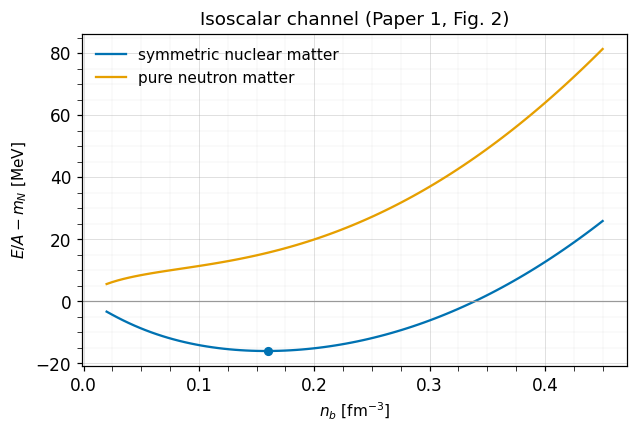

In [4]:
SPECIES = ("p", "n", "Lambda", "u", "d", "s", "e", "mu")


def dens(**kwargs):
    """Density dict in MeV^3 from fm^-3 keyword arguments.

    Unnamed species default to zero:  dens(p=0.08, n=0.08)
    """
    bad = set(kwargs) - set(SPECIES)
    if bad:
        raise KeyError(f"unknown species {sorted(bad)}; expected {SPECIES}")
    return {sp: kwargs.get(sp, 0.0) * hc3 for sp in SPECIES}


def snm(nb_fm):
    """Symmetric nuclear matter at n_b [fm^-3]."""
    return dens(p=nb_fm / 2.0, n=nb_fm / 2.0)


def pnm(nb_fm):
    """Pure neutron matter at n_b [fm^-3]."""
    return dens(n=nb_fm)


def sweep(nb_grid, composition, par=None):
    """Solve a fixed-composition sequence; returns a dict of fm-based arrays.

    `composition` maps n_b [fm^-3] to a density dict, e.g. `snm` above. Each
    point is seeded from the previous converged quark masses, which is what
    keeps a density sweep on one branch.
    """
    out = {k: [] for k in ("n_b", "eps", "P", "EperB", "M_u", "M_d", "M_s")}
    seed = None
    for x in nb_grid:
        pt = solve_point(composition(x), par=par, x0=seed)
        seed = [pt.M_q["u"], pt.M_q["d"], pt.M_q["s"]]
        out["n_b"].append(pt.n_b_fm)
        out["eps"].append(pt.eps_fm)
        out["P"].append(pt.P_fm)
        out["EperB"].append(pt.EperB)
        for q in "uds":
            out[f"M_{q}"].append(pt.M_q[q])
    return {k: np.asarray(v) for k, v in out.items()}


grid = np.linspace(0.02, 0.45, 90)
E_snm = sweep(grid, snm, par=par)["EperB"]
E_pnm = sweep(grid, pnm, par=par)["EperB"]

i0 = int(np.argmin(E_snm))
# parabola through the three points about the minimum: the grid is coarser
# than the difference between 0.158 and its neighbours would be readable at
a, b, c = E_snm[i0 - 1], E_snm[i0], E_snm[i0 + 1]
step = grid[1] - grid[0]
n_sat = grid[i0] + 0.5 * step * (a - c) / (a - 2.0 * b + c)
E_sat = b - 0.125 * (a - c) ** 2 / (a - 2.0 * b + c)
print(f"saturation: n_0 = {n_sat:.3f} fm^-3, E/A = {E_sat:.2f} MeV"
      f"   (published 0.158, -16.0)")
print(f"symmetry energy S(0.158) = "
      f"{solve_point(pnm(0.158), par=par).EperB - solve_point(snm(0.158), par=par).EperB:.2f} MeV"
      f"   (published 31.5)")
print(f"                S(0.100) = "
      f"{solve_point(pnm(0.100), par=par).EperB - solve_point(snm(0.100), par=par).EperB:.2f} MeV"
      f"   (published 25.5)")

fig, ax = plt.subplots()
ax.plot(grid, E_snm, color=OKAB_CAT[0], label="symmetric nuclear matter")
ax.plot(grid, E_pnm, color=OKAB_CAT[1], label="pure neutron matter")
ax.axhline(0.0, color="0.6", lw=0.8)
ax.plot([grid[i0]], [E_snm[i0]], "o", color=OKAB_CAT[0], ms=5)
ax.set_xlabel(r"$n_b$ [fm$^{-3}$]")
ax.set_ylabel(r"$E/A - m_N$ [MeV]")
ax.set_title("Isoscalar channel (Paper 1, Fig. 2)")
apply_style(ax)
plt.show()

## 4. Chiral restoration and the condensate cap

The gap equation is driven by the **effective** scalar density
$\bar n^s_q = n^s_q + \alpha_S \sum_i N^q_i\, n^s_i$ (Eq. (6)) — the quark
scalar density *including* its cut-off-regularized vacuum term, plus the
baryon cluster contribution. It is negative in vacuum and rises to zero as
chiral symmetry is restored.

**It is capped there.** The cluster term is positive and grows with baryon
density, so the raw expression turns positive at high density (reaching
$+2.5$ fm⁻³ at $n_b = 10$ fm⁻³) — which would be a condensate of the wrong
sign and would push $M_q$ *below* its current mass. `eos.enjl` caps
$\bar n^s_q \le 0$, so $M_q \ge m_{q0}$ always. This is what the reference
tables do: their `Sigmaq` columns are written as exactly 0 on precisely those
rows.

The plot below follows the quark masses along the composition of one
reference table. The flat sections at $M_u = M_d = 5.5$ MeV are the capped
region.

Beta_fq0.7_B1.dat: re-solved 273 rows at their own composition


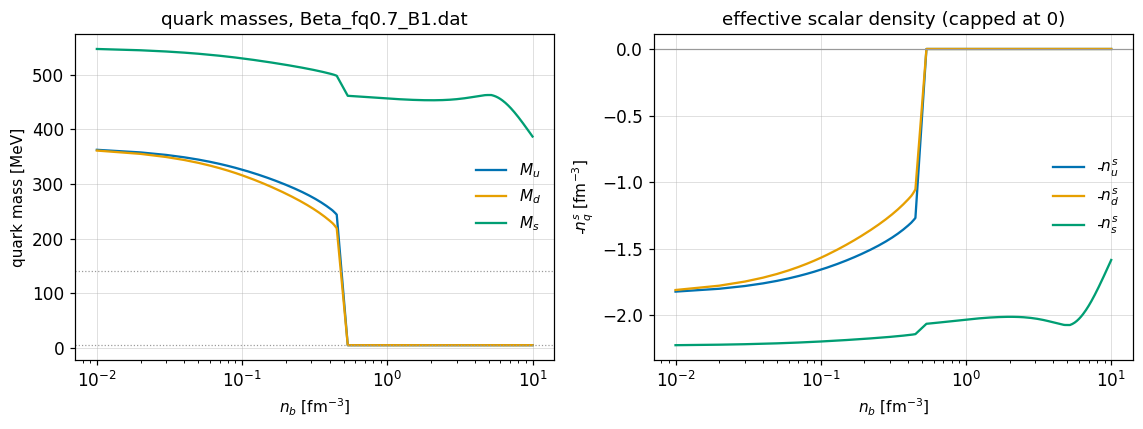

In [5]:
#: model species name -> reference-table column suffix. The tables write "L"
#: for the Lambda hyperon; every other name coincides.
REF_COL = {"p": "p", "n": "n", "Lambda": "L", "u": "u", "d": "d", "s": "s",
           "e": "e", "mu": "mu"}


def load_case(filename):
    """(columns, usable-row mask, params) for one reference file.

    `solved_rows` drops the interpolated mixed-phase rows of the f_q = 0.5
    file; `bad_rows` drops the non-converged rows of the f_q = 0.7, B = 0 one.
    Never run a quantitative comparison without both masks.
    """
    f_q, B_GeV = PARAMETER_SETS[filename]
    col = load_reference(filename)
    return (col, solved_rows(col) & ~bad_rows(col, filename),
            ENJLParams(f_q=f_q, B_GeV_fm3=B_GeV))


def solve_reference_rows(filename):
    """Re-solve every usable row of a reference file at its own composition.

    Returns (columns, params, [(row index, ENJLEoSPoint), ...]). Each gap solve
    is seeded from that row's printed quark masses, which selects the branch
    without fixing the answer — the converged root is set by the equation.
    """
    col, ok, par_file = load_case(filename)
    out = []
    for i in np.flatnonzero(ok):
        n_i = {name: col["n" + suf][i] * hc3 for name, suf in REF_COL.items()}
        seed = [col["Mu"][i], col["Md"][i], col["Ms"][i]]
        out.append((i, solve_point(n_i, par=par_file, x0=seed)))
    return col, par_file, out


FILE = "Beta_fq0.7_B1.dat"
col, par_ref, rows = solve_reference_rows(FILE)
nb = np.array([col["nB"][i] for i, _ in rows])
print(f"{FILE}: re-solved {len(rows)} rows at their own composition")
fig, (axa, axb) = plt.subplots(1, 2, figsize=(10.5, 4.0))
for q, c in zip("uds", OKAB_CAT):
    axa.plot(nb, [pt.M_q[q] for _, pt in rows], color=c, label=f"$M_{q}$")
    axb.plot(nb, [pt.nbar_s[q] / hc3 for _, pt in rows], color=c,
             label=rf"$\bar n^s_{q}$")
axa.axhline(par_ref.m_s0, color="0.6", lw=0.8, ls=":")
axa.axhline(par_ref.m_u0, color="0.6", lw=0.8, ls=":")
axa.set_ylabel("quark mass [MeV]")
axb.axhline(0.0, color="0.6", lw=0.8)
axb.set_ylabel(r"$\bar n^s_q$ [fm$^{-3}$]")
for a in (axa, axb):
    a.set_xlabel(r"$n_b$ [fm$^{-3}$]")
    a.set_xscale("log")
    apply_style(a, minor_ticks=False)
axa.set_title(f"quark masses, {FILE}")
axb.set_title("effective scalar density (capped at 0)")
plt.tight_layout()
plt.show()

## 5. Against the reference tables

The check that matters: hand `solve_point` each table row's **own** species
densities and compare what comes back. This exercises the gap equation, the
baryon masses of Eq. (4), the vector sources, both rearrangement terms and
the $E_0$ subtraction, with no root finding on the composition.

The gap solve is seeded from the row's printed masses. That is not circular:
the seed only selects which root the solver converges to, and the root is
fixed by the equation. If the algebra were wrong the root would move.

This is the same comparison that `test/enjl/test_enjl_fixed_composition.py`
gates; here it is plotted so the structure is visible.

Beta_fq0.7_B1.dat: worst |Delta mu_i| = 3.740e-02 MeV over 273 rows
          worst |Delta P|/P = 4.649e-04
gates in test_enjl_fixed_composition.py: 4.0e-2 MeV and 4.9e-4

all five parameter sets:
  Beta_fq1.0_B0.dat      280 rows   max |dmu| 3.34e-02 MeV   max |dP|/P 1.76e-04
  Beta_fq1.0_B1.dat      277 rows   max |dmu| 4.72e-03 MeV   max |dP|/P 1.28e-05
  Beta_fq0.7_B0.dat      244 rows   max |dmu| 2.62e-01 MeV   max |dP|/P 2.10e-04
  Beta_fq0.7_B1.dat      273 rows   max |dmu| 3.74e-02 MeV   max |dP|/P 4.65e-04
  Beta_fq0.5_B1.dat      180 rows   max |dmu| 2.02e-01 MeV   max |dP|/P 7.02e-05


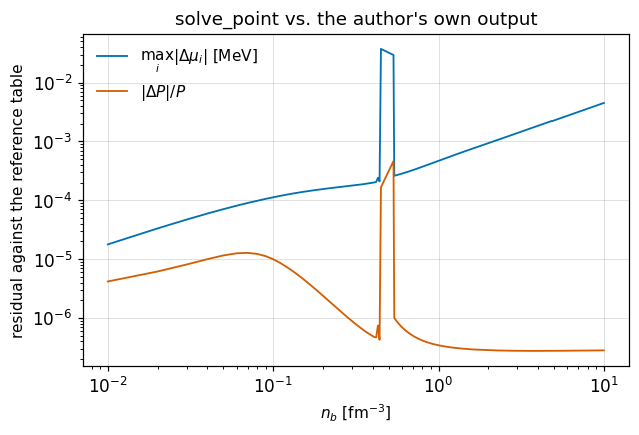

In [6]:
def compare_to_table(col, rows):
    """Per-row worst |Delta mu_i| [MeV] and relative |Delta P|.

    mu is compared only for species that are actually present: below its onset
    a species has no equilibrium potential, and the tables print the threshold
    value the reference solver last held for it — comparing there gives
    residuals of hundreds of MeV that mean nothing.
    """
    mu_err, P_err = [], []
    for i, pt in rows:
        worst = 0.0
        for name in ("p", "n", "Lambda", "u", "d", "s"):
            suf = REF_COL[name]
            if col["n" + suf][i] > 1.0e-4 * col["nB"][i]:
                worst = max(worst, abs(pt.mu[name] - col["mu" + suf][i]))
        mu_err.append(worst)
        P_err.append(abs(pt.P / hc3 - col["P"][i]) / max(abs(col["P"][i]), 1e-3))
    return np.asarray(mu_err), np.asarray(P_err)


mu_err, P_err = compare_to_table(col, rows)
print(f"{FILE}: worst |Delta mu_i| = {mu_err.max():.3e} MeV over {len(rows)} rows")
print(f"          worst |Delta P|/P = {P_err.max():.3e}")
print("gates in test_enjl_fixed_composition.py: 4.0e-2 MeV and 4.9e-4")

print("\nall five parameter sets:")
for name in PARAMETER_SETS:
    c_i, _, r_i = solve_reference_rows(name)
    m_i, p_i = compare_to_table(c_i, r_i)
    print(f"  {name:22s} {len(r_i):3d} rows   "
          f"max |dmu| {m_i.max():.2e} MeV   max |dP|/P {p_i.max():.2e}")

fig, ax = plt.subplots()
ax.semilogy(nb, mu_err, color=OKAB_CAT[0], lw=1.2,
            label=r"$\max_i |\Delta\mu_i|$ [MeV]")
ax.semilogy(nb, P_err, color=OKAB_CAT[3], lw=1.2, label=r"$|\Delta P| / P$")
ax.set_xscale("log")
ax.set_xlabel(r"$n_b$ [fm$^{-3}$]")
ax.set_ylabel("residual against the reference table")
ax.set_title("solve_point vs. the author's own output")
apply_style(ax, minor_ticks=False)
plt.show()

The residual spikes at the chiral transition ($n_b \approx 0.45$ fm⁻³ for
this parameter set) and is at the $10^{-6}$ level everywhere else. That is
expected: at a first-order transition two roots of the gap equation are
nearly degenerate, so the sensitivity of $M_q$ to any difference in
convergence is at its largest exactly there.

## 6. Beta equilibrium — works below the transition, not through it

`solve_beta_point(n_b)` solves Eqs. (23)-(24) simultaneously with the mean
field, so it produces the composition rather than consuming it. Below the
first-order transition it reproduces the reference table to the printed
digits. Above it, the continuation is not yet in place and the solve fails.

**This is the next milestone, not a bug to work around.** Do not build on
`solve_beta_point` above the transition density of your parameter set.

In [7]:
def beta_eos(nb_grid, par=None):
    """Beta-equilibrium EoS along a density grid, stopping at the first failure.

    Returns (points, n_b, eps, P) with the arrays truncated at whatever the
    solver actually reached. It stops rather than skipping, because a gap in a
    continuation sequence means the points after it are no longer warm-started
    from a neighbouring solution and cannot be trusted to be on the same
    branch.
    """
    pts, seed = [], None
    for x in nb_grid:
        try:
            bp = solve_beta_point(x, par=par, x0=seed)
        except RuntimeError as exc:
            print(f"  stopped at n_b = {x:.3f} fm^-3: {str(exc)[:96]}")
            break
        pts.append(bp)
        seed = (bp.M_q["u"], bp.M_q["d"], bp.M_q["s"], bp.mu_b, bp.mu_e,
                sum(bp.densities[q] for q in "uds") / 3.0 * hc3,
                bp.pt.gomega_omega, bp.pt.grho_rho,
                bp.pt.SigmaR_b, bp.pt.SigmaR_q)
    return (pts, np.array([p.n_b_fm for p in pts]),
            np.array([p.eps for p in pts]), np.array([p.P for p in pts]))


mu_b_table = baryon_potential(col)
print(f"{'n_b':>6s} {'P ours':>10s} {'P table':>10s} {'mu_b ours':>11s} "
      f"{'mu_b table':>11s} {'n_p ours':>9s} {'n_p table':>10s}")
for x in (0.10, 0.20, 0.30, 0.40, 0.60, 1.00):
    j = int(np.argmin(abs(col["nB"] - x)))
    try:
        bp = solve_beta_point(x, par=par_ref)
        print(f"{x:6.2f} {bp.P:10.3f} {col['P'][j]:10.3f} {bp.mu_b:11.2f} "
              f"{mu_b_table[j]:11.2f} {bp.densities['p']:9.4f} "
              f"{col['np'][j]:10.4f}")
    except RuntimeError:
        print(f"{x:6.2f} {'--- solve failed (above the chiral transition) ---':>52s}")

print("\ncontinuation sweep with beta_eos():")
_, nb_beta, eps_beta, P_beta = beta_eos(np.arange(0.05, 1.01, 0.05), par=par_ref)
print(f"  reached n_b = {nb_beta.max():.2f} fm^-3 "
      f"({len(nb_beta)} points), P = {P_beta.max():.2f} MeV/fm^3")

   n_b     P ours    P table   mu_b ours  mu_b table  n_p ours  n_p table
  0.10      0.465      0.465      953.77      953.77    0.0039     0.0039
  0.20      4.475      4.475      979.02      979.02    0.0110     0.0110
  0.30     18.274     18.274     1033.21     1033.21    0.0211     0.0211
  0.40     48.184     48.184     1117.95     1117.95    0.0342     0.0342
  0.60   --- solve failed (above the chiral transition) ---
  1.00   --- solve failed (above the chiral transition) ---

continuation sweep with beta_eos():
  stopped at n_b = 0.550 fm^-3: ENJL beta-equilibrium solve failed at n_b=0.5500 fm^-3: success=True cost=6.686e-07
  reached n_b = 0.50 fm^-3 (10 points), P = 95.56 MeV/fm^3


## 7. Things that will cost you an afternoon

**Units.** Natural units inside `eos.enjl.uniform` and
`eos.enjl.thermodynamics` (MeV, MeV³, MeV⁴); fm-based on the public
properties. `hc3` converts. Never let natural units cross a module boundary.

**The reference tables have four misleading columns.** All handled by the
helpers in `test/enjl/reference/`, but if you read the `.dat` files directly:

| column | trap |
|---|---|
| `nsq` | quark scalar density **without** the vacuum term. The gap equation does *not* take this. |
| `Sigmaq` | the effective $\bar n^s_q$ **with** it. This is what the gap equation takes. |
| `munr` | the baryon chemical potential $\mu_b$ — **not** `mun`. They agree while baryons exist and differ by hundreds of MeV once they dissolve, where $\mu_b = \mu_u + 2\mu_d$. |
| `mue`, `mumu` | written as the lepton *mass* when that lepton is absent. $\mu_e$ is still nonzero there and equals $\mu_d - \mu_u$. |

Use `load_reference`, `solved_rows`, `bad_rows`, `baryon_potential`,
`electron_potential` and `present` rather than reading columns raw. In
particular `Beta_fq0.5_B1.dat` is 180 solved rows plus 203 rows of linear
interpolation across two Maxwell plateaus; fitting to those produces nonsense.

**Charge conventions.** `eos.enjl` follows the paper and uses the physical
electric charge $q_i$ in Eqs. (23)-(24). The repo-wide non-leptonic charge
$C$ and strangeness $S = +1$ per $s$ quark are carried on the `Species`
records for when this engine is coupled to `eos.mixed`; translating between
them is the adapter's job, not the model's.

**The condensate cap** (§4) is a pinned decision, recorded in
`DD2_OPEN_QUESTIONS.md` §G1. Without it the solver does not merely lose
accuracy — the gap equation acquires spurious negative-mass roots.

## 8. What is not here yet

* **Beta equilibrium through the transition** — continuation in density past
  the first-order transitions (§6).
* **Maxwell construction** — the reference tables contain four verified
  coexistence windows to test one against.
* **TOV sequences** — `eos.tov` is ready; it needs a table that spans the
  full density range, which needs the two items above.
* **Finite temperature** — the whole extension is one function: route the
  kinetic block to `eos.general.fermi_integrals.solve_fermi_jel` for the
  medium part and keep the $\Lambda$ vacuum term analytic, since it is
  temperature-independent. `eos.dd2.physics.thermo.kinetic_thermo` is that
  pattern for the nucleonic sector.
* **Mixed phases** — deferred. Note that ENJL is *one* engine describing both
  phases, so whether `eos.mixed`'s two-engine $\eta$ machinery applies
  unchanged is an open question, not a given.

In [8]:
print("notebook completed")

notebook completed
